# Лаб №5
## Нахождение числовых характеристик выборки стандартными средствами ЭТ MS Excel

##  заданиe

Для выборк  из таблицы 2 на странице 63 необходимо выполнить описательную статистику стандартными средствами и сравнить результаты с расчётом по формулам на Python. Нужно найти выборочное среднее, медиану, моду, исправленную дисперсию, стандартное отклонение, стандартную ошибку, минимум, максимум, размах, коэффициент асимметрии, эксцесс, а также параметры группировки для построения гистограммы.

## данные

Выборка объёма `n = 27` (таблица 2, страница 63):

```text
18.7, 16.3, 18.4, 19.3, 18.8, 19.4, 18.7, 18.5, 20.6, 20.6, 19.4, 20.7, 16.3, 18.4, 19.3, 18.8, 18.4, 19.3, 19.3, 19.9, 23.1, 18.8, 17.4, 21.6, 19.1, 18.4, 19.3
```



### Формулы контроля для сверки расчетов "вручную"


* **Выборочное среднее:** 
$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$$


* **Исправленная дисперсия (несмещенная):** 
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$


* **Коэффициент асимметрии:** 
$$A_s = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$


* **Эксцесс:** 
$$E_k = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

In [37]:
import math
from statistics import multimode
import numpy as np
import matplotlib.pyplot as plt

sample = [
    18.7, 16.3, 18.4, 19.3, 18.8, 19.4, 18.7, 18.5, 20.6, 
    20.6, 19.4, 20.7, 16.3, 18.4, 19.3, 18.8, 18.4, 19.3, 
    19.3, 19.9, 23.1, 18.8, 17.4, 21.6, 19.1, 18.4, 19.3
]

data = np.asarray(sample, dtype=float)

n = int(data.size)

In [38]:
data_sum = float(data.sum())
mean = float(data.mean())
median = float(np.median(data))
modes = sorted(multimode(data.tolist()))
data_min = float(data.min())
data_max = float(data.max())
data_range = data_max - data_min


### 1. Сумма квадратов отклонений 
$$SS = \sum_{i=1}^{n} (x_i - \bar{x})^2$$
*Где $x_i$ — конкретное значение выборки, $\bar{x}$ — выборочное среднее, а $n$ — объём выборки.*

### 2. Исправленная /несмещенная  выборочная дисперсия 
$$s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$
*Где $s^2$ — исправленная дисперсия.*

### 3. Исправленное выборочное стандартное / среднеквадратическое отклонение 
Возвращает показатель разброса к исходным единицам измерения данных (избавляя от квадрата).
$$s = \sqrt{s^2} = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}$$
*Где $s$ — стандартное отклонение.*

### 4. Стандартная ошибка среднего 
Показывает величину изменчивости выборочного среднего значения и определяет, насколько точно выборочное среднее оценивает истинное среднее генеральной совокупности.
$$m_x = S.E. = \frac{s}{\sqrt{n}}$$
*Где $m_x$ (или $S.E.$) — стандартная ошибка.*

In [39]:
sum_sq_dev = float(np.sum((data - mean) ** 2)) # сумма кв отклонений 
variance = sum_sq_dev / (n - 1) # несмещенная дисперсия 
std_dev = math.sqrt(variance) # среднеквадратическое отклонение
stderr = std_dev / math.sqrt(n) 

### 1. Стандартизированные значения 
Z-масштабирование (нормирование) данных, которое показывает, на сколько стандартных отклонений каждый элемент выборки удален от среднего значения.
$$z_i = \frac{x_i - \bar{x}}{s}$$
*Где $x_i$ — значение выборки, $\bar{x}$ — выборочное среднее, $s$ — стандартное отклонение.*

### 2. Коэффициент асимметрии 
Показывает степень скошенности  распределения относительно его среднего значения. Здесь используется точная несмещенная оценка для малых выборок.
$$As = \frac{n}{(n - 1)(n - 2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$
*Где $As$ — коэффициент асимметрии, а $n$ — объём выборки.*

### 3. Коэффициент эксцесса 
Показывает «островершинность» или «крутость» распределения в сравнении с нормальным распределением. Из итогового значения вычитается 3 (в формуле это скорректировано для малых выборок), чтобы для нормального распределения эксцесс был равен нулю.
$$Ek = \frac{n(n + 1)}{(n - 1)(n - 2)(n - 3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n - 1)^2}{(n - 2)(n - 3)}$$
*Где $Ek$ — коэффициент эксцесса.*

### 4. 95%-й доверительный интервал для среднего 
Интервал, который с вероятностью 95% покрывает истинное )среднее значение. Коэффициент 2 аппроксимирует критическое значение для данной надежности.

**Полуширина интервала :**
$$\Delta\% = 2 \cdot m_x$$

**Границы интервала (нижняя и верхняя):**
$$CI = \left[ \bar{x} - 2\cdot m_x; \quad \bar{x} + 2\cdot m_x \right]$$
*Где $\bar{x}$ — выборочное среднее, а $m_x$ — стандартная ошибка среднего (`stderr`).*

In [40]:
# Асимметрия и эксцесс
standardized = (data - mean) / std_dev
sum_std3 = float(np.sum(standardized ** 3))
sum_std4 = float(np.sum(standardized ** 4))

skewness = n / ((n - 1) * (n - 2)) * sum_std3
excess = (
    n * (n + 1) / ((n - 1) * (n - 2) * (n - 3)) * sum_std4
    - 3 * (n - 1) ** 2 / ((n - 2) * (n - 3))
)

# 95%-й доверительный интервал для среднего
ci_half = 2 * stderr
ci_low = mean - ci_half
ci_high = mean + ci_half

### 1. Определение количества интервалов (групп) 
Использует правило корня для примерного определения оптимального числа интервалов группировки, защищая от получения нулевого значения.
$$k = \max(1, \lfloor \sqrt{n} \rceil)$$
*Где $k$ — округленное число интервалов (`bins_round`), а $n$ — объём выборки.*

### 2. Шаг группировки (ширина интервала) 
Разбивает весь диапазон выборки от минимума до максимума на $k$ равных частей. Ширина каждого интервала $h$ вычисляется как разность между его границами.
$$h = \frac{X_{max} - X_{min}}{k}$$
*Где $X_{max}$ и $X_{min}$ — максимальное и минимальное значения выборки.*

### 3. Относительная частота 
Показывает долю элементов выборки, попавших в конкретный $j$-й интервал.
$$p_j = \frac{m_j}{n}$$
*Где $m_j$ — абсолютная частота интервала (`counts`), а $n$ — общий объём выборки.*

### 4. Плотность относительной частоты 
Показывает долю элементов, приходящуюся на единицу длины интервала. Именно эта величина определяет высоту столбиков на гистограмме, благодаря чему общая площадь всех столбиков становится равной 1.
$$f_j = \frac{p_j}{h} = \frac{m_j}{n \cdot h}$$
*Где $p_j$ — относительная частота, а $h$ — ширина интервала (`widths`).*

### 5. Середины интервалов 
Вычисляются для нахождения центральных точек каждого интервала, которые часто используются для построения полигона частот или центрирования подписей.
$$x_{mid, j} = \frac{x_j + x_{j+1}}{2}$$
*Где $x_j$ и $x_{j+1}$ — левая и правая границы (`edges`) конкретного интервала.*

In [41]:
bins_float = math.sqrt(n)
bins_round = max(1, round(bins_float))
# границ интервалов
edges = np.linspace(data_min, data_max, bins_round + 1)
# Массив количеств  сколько чисел попало в каждый интервал.
# Массив самих границ
counts, _ = np.histogram(data, bins=edges)
widths = np.diff(edges)
relative_frequency = counts / n
density = counts / (n * widths)
midpoints = (edges[:-1] + edges[1:]) / 2

ИНТЕРВАЛЬНЫЙ РЯД СГРУППИРОВАННЫХ ДАННЫХ
Интервал           | Частота | Отн. частота | Плотность
--------------------------------------------------------
[16.30; 17.66)     |       3 |       0.1111 |    0.0817
[17.66; 19.02)     |      10 |       0.3704 |    0.2723
[19.02; 20.38)     |       9 |       0.3333 |    0.2451
[20.38; 21.74)     |       4 |       0.1481 |    0.1089
[21.74; 23.10]     |       1 |       0.0370 |    0.0272

ОПИСАТЕЛЬНАЯ СТАТИСТИКА
Объём выборки (n):          27
Сумма значений:            516.8000
Выборочное среднее (x_ср):  19.1407
Медиана (Me):               19.1000
Мода (Mo):                  19.30
Минимум (X_min):            16.3000
Максимум (X_max):           23.1000
Размах выборки (R):         6.8000
Исправленная дисперсия (s²): 1.9910
Стандартное отклонение (s): 1.4110
Стандартная ошибка (m_x):   0.2716
Коэффициент асимметрии (As):0.5047
Эксцесс (Ek):               1.9815
95% ДИ для среднего:       [18.5976; 19.6838]


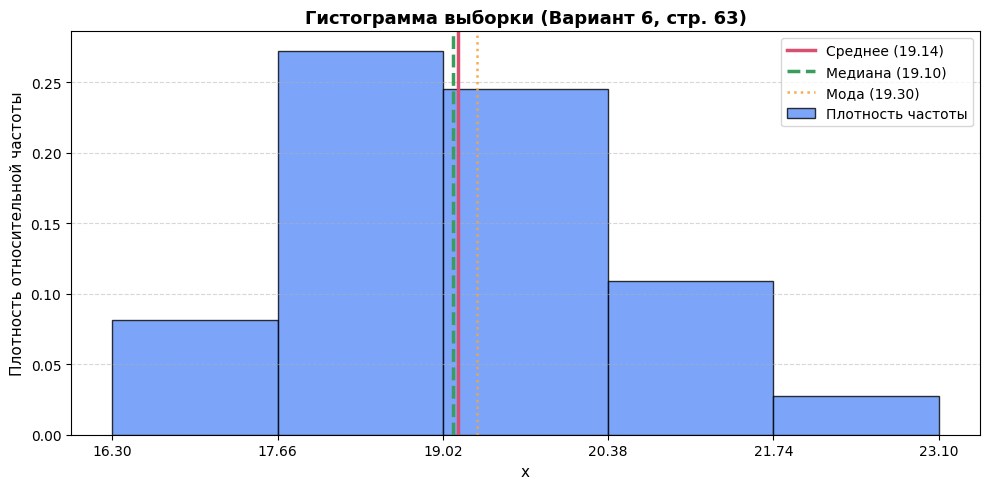

In [42]:
print('=' * 56)
print('ИНТЕРВАЛЬНЫЙ РЯД СГРУППИРОВАННЫХ ДАННЫХ')
print('=' * 56)
print(f"{'Интервал':<18} | {'Частота':>7} | {'Отн. частота':>12} | {'Плотность':>9}")
print('-' * 56)
for idx in range(bins_round):
    left = edges[idx]
    right = edges[idx + 1]
    interval_label = f'[{left:.2f}; {right:.2f}]' if idx == bins_round - 1 else f'[{left:.2f}; {right:.2f})'
    print(f"{interval_label:<18} | {counts[idx]:>7d} | {relative_frequency[idx]:>12.4f} | {density[idx]:>9.4f}")
print('=' * 56)

print('\n' + '=' * 56)
print('ОПИСАТЕЛЬНАЯ СТАТИСТИКА')
print('=' * 56)
print(f'Объём выборки (n):          {n}')
print(f'Сумма значений:            {data_sum:.4f}')
print(f'Выборочное среднее (x_ср):  {mean:.4f}')
print(f'Медиана (Me):               {median:.4f}')
print(f'Мода (Mo):                  {", ".join(f"{m:.2f}" for m in modes)}')
print(f'Минимум (X_min):            {data_min:.4f}')
print(f'Максимум (X_max):           {data_max:.4f}')
print(f'Размах выборки (R):         {data_range:.4f}')
print(f'Исправленная дисперсия (s²): {variance:.4f}')
print(f'Стандартное отклонение (s): {std_dev:.4f}')
print(f'Стандартная ошибка (m_x):   {stderr:.4f}')
print(f'Коэффициент асимметрии (As):{skewness:.4f}')
print(f'Эксцесс (Ek):               {excess:.4f}')
print(f'95% ДИ для среднего:       [{ci_low:.4f}; {ci_high:.4f}]')
print('=' * 56)

plt.figure(figsize=(10, 5))

plt.bar(midpoints, density, width=widths, align='center', color='#5B8FF9', edgecolor='black', alpha=0.8, label='Плотность частоты')

plt.axvline(mean, color='#D94F70', linewidth=2.5, label=f'Среднее ({mean:.2f})')
plt.axvline(median, color='#3A9D5D', linewidth=2.5, linestyle='--', label=f'Медиана ({median:.2f})')

for i, mode in enumerate(modes):
    label = f'Мода ({mode:.2f})' if i == 0 else f'_Мода_{mode:.2f}'
    plt.axvline(mode, color='#F2A541', linewidth=1.8, linestyle=':', alpha=0.9, label=label)

plt.title('Гистограмма выборки (Вариант 6, стр. 63)', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('Плотность относительной частоты', fontsize=11)
plt.xticks(edges)  # Подписи по границам интервалов
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()